# Water Quality PINN: Chl-a from Landsat 8

**Author:** Maya Struzak  
**Course:** Physics-Informed Machine Learning (12-787), Carnegie Mellon University  
**Date:** Spring 2026  


## Setup
Data:



*   AquaSat v1 (Ross et al., 2019) — Landsat 8 subset. Download from Figshare: https://doi.org/10.6084/m9.figshare.8139383
*   Chesapeake Bay watershed boundary (HUC-4) from USGS/FWS: https://gis-fws.opendata.arcgis.com/datasets/chesapeake-bay-watershed-boundary/explore?location=39.826191%2C-77.565341%2C5

## Imports

In [1]:
!pip install cartopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

warnings.filterwarnings("ignore")

# Download AquaSat from Figshare: https://doi.org/10.6084/m9.figshare.8139383
# Update path to your local copy of sr_wq_rs_join.csv
df_fp = "sr_wq_rs_join.csv"
df = pd.read_csv(df_fp)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 16.7 MB/s eta 0:00:00
Mounted at /content/drive


# National Dataset

## Data Prep

### clean and filter

In [2]:
BAND_COLS = ["blue", "green", "red", "nir", "swir1", "swir2"]
TARGET = "chl_a"
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# filter for landsat 8
df8 = df[df["sat"] == 8].copy()

# filter valid chl_a
df8 = df8[(df8[TARGET].notna()) & (df8[TARGET] > 0)]

# rescale bands from scaled integers to true reflectance (0-1)
for col in BAND_COLS:
    df8[col] = df8[col] / 10000.0

# remove physically impossible reflectance values
df8 = df8[(df8[BAND_COLS] >= 0).all(axis=1) &
          (df8[BAND_COLS] <= 1.0).all(axis=1)].copy()

# remove chl-a outliers
df8 = df8[(df8[TARGET] >= 0.1) & (df8[TARGET] <= 500)].copy()

# filter for reliable pixel counts (3x3 Landsat pixel window)
df8 = df8[df8["pixelCount"] >= 9].copy()

# log-transform target
df8["log_chl"] = np.log(df8[TARGET])

# engineered features
df8["green_red"]  = df8["green"] / df8["red"]
df8["nir_red"]    = df8["nir"]   / df8["red"]
df8["blue_green"] = df8["blue"]  / df8["green"]
df8["nir_green"]  = df8["nir"]   / df8["green"]

# get tertiles for plotting
df8["chl_tertile"] = pd.qcut(df8[TARGET], q=3, labels=["low", "mid", "high"])

print(f"Final dataset: {len(df8):,} rows")
print(f"Chl-a range: {df8[TARGET].min():.2f} – {df8[TARGET].max():.2f} µg/L")
print(f"Log(chl) mean ± std: {df8['log_chl'].mean():.2f} ± {df8['log_chl'].std():.2f}")
print(f"\nBand ranges:")
for col in BAND_COLS:
    print(f"  {col:<8} min={df8[col].min():.4f}  max={df8[col].max():.4f}  mean={df8[col].mean():.4f}")

Final dataset: 15,827 rows
Chl-a range: 0.10 – 495.00 µg/L
Log(chl) mean ± std: 1.98 ± 1.28

Band ranges:
  blue     min=0.0003  max=0.9337  mean=0.0310
  green    min=0.0029  max=0.9070  mean=0.0413
  red      min=0.0000  max=0.9368  mean=0.0307
  nir      min=0.0000  max=0.9685  mean=0.0280
  swir1    min=0.0002  max=0.6972  mean=0.0155
  swir2    min=0.0000  max=0.4564  mean=0.0118


### plot chl-a ditributions

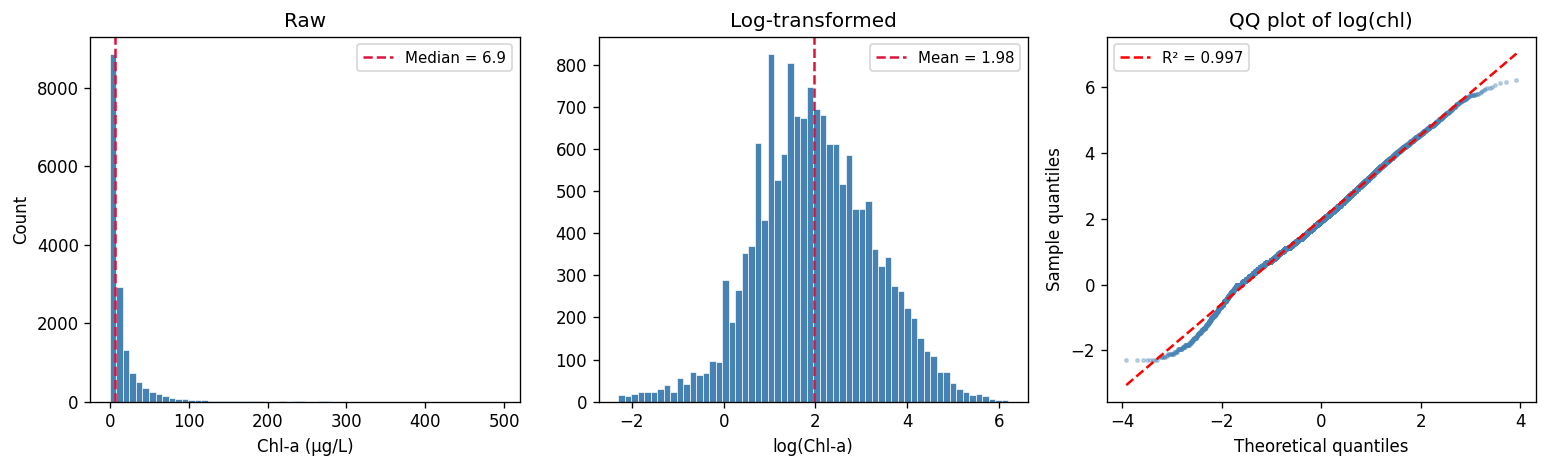

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# fig.suptitle("Chl-a distribution", fontweight="bold")

# plot raw chl-a dist
axes[0].hist(df8[TARGET], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Chl-a (µg/L)")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw")
axes[0].axvline(df8[TARGET].median(), color="crimson", ls="--", lw=1.5,
                label=f"Median = {df8[TARGET].median():.1f}")
axes[0].legend(fontsize=9)

# plot log tranformed chla
axes[1].hist(df8["log_chl"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("log(Chl-a)")
axes[1].set_title("Log-transformed")
axes[1].axvline(df8["log_chl"].mean(), color="crimson", ls="--", lw=1.5,
                label=f"Mean = {df8['log_chl'].mean():.2f}")
axes[1].legend(fontsize=9)

# qq plot
(osm, osr), (slope, intercept, r) = stats.probplot(df8["log_chl"], dist="norm")
axes[2].scatter(osm, osr, s=4, alpha=0.3, color="steelblue")
axes[2].plot([osm.min(), osm.max()],
             [slope*osm.min()+intercept, slope*osm.max()+intercept],
             "r--", lw=1.5, label=f"R² = {r**2:.3f}")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")
axes[2].set_title("QQ plot of log(chl)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

Raw (left): heavy right-skew means most water bodies have low chl-a (cllean water)

log transform (center): log-a transform produces apx. normal dist bell curve

qq plot (right): confirmation of high normality of log-transformed data

### plot spectral signatures

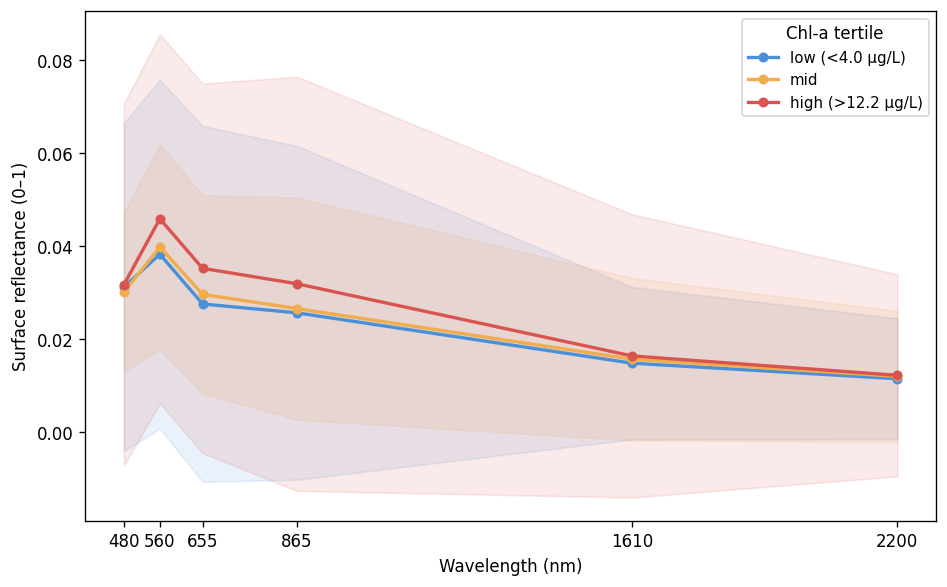

In [4]:
# define values for plotting
low_thresh  = df8[TARGET].quantile(0.33)
high_thresh = df8[TARGET].quantile(0.67)
wavelengths = [480, 560, 655, 865, 1610, 2200]

#plot
fig, ax = plt.subplots(figsize=(8, 5))
palette = {"low": "#4a90d9", "mid": "#f0ad4e", "high": "#d9534f"}

for group, color in palette.items():
    subset = df8[df8["chl_tertile"] == group]
    means  = [subset[c].mean() for c in BAND_COLS]
    stds   = [subset[c].std()  for c in BAND_COLS]
    label  = (f"low (<{low_thresh:.1f} µg/L)" if group == "low" else
              f"mid"                            if group == "mid" else
              f"high (>{high_thresh:.1f} µg/L)")
    ax.plot(wavelengths, means, color=color, lw=2, marker="o", ms=5, label=label)
    ax.fill_between(wavelengths,
                    [m-s for m,s in zip(means,stds)],
                    [m+s for m,s in zip(means,stds)],
                    color=color, alpha=0.12)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Surface reflectance (0–1)")
# ax.set_title("Mean Landsat 8 spectra by chl-a tertile\n(shaded = ±1 std)")
ax.legend(title="Chl-a tertile", fontsize=9)
ax.set_xticks(wavelengths)
plt.tight_layout()
plt.show()

### correlations

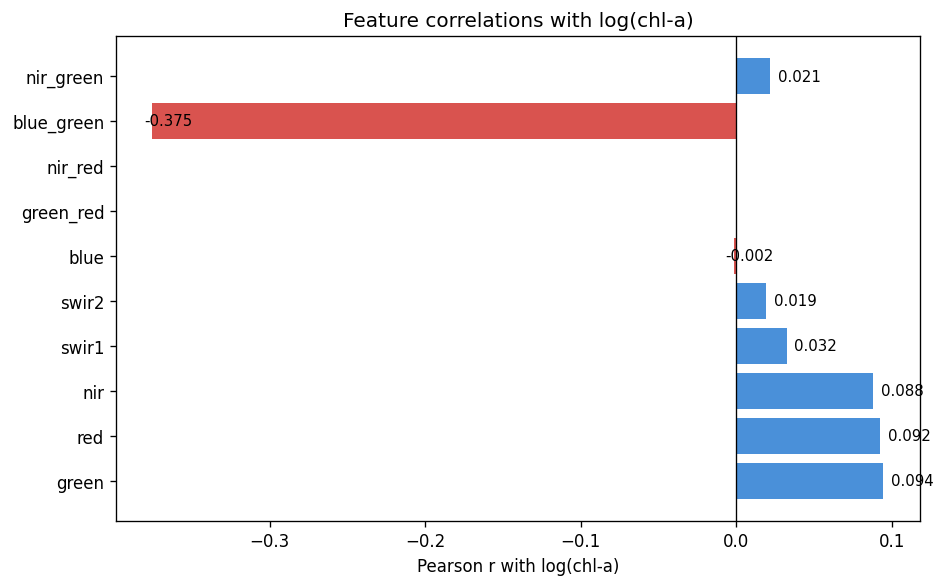

In [5]:
features = ["blue", "green", "red", "nir", "swir1", "swir2",
            "green_red", "nir_red", "blue_green", "nir_green"]

corrs = [(f, df8[f].corr(df8["log_chl"])) for f in features]
corrs_sorted = sorted(corrs, key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(8, 5))
labels = [f for f, _ in corrs_sorted]
values = [r for _, r in corrs_sorted]
colors = ["#d9534f" if r < 0 else "#4a90d9" for r in values]

ax.barh(labels, values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with log(chl-a)")
ax.set_title("Feature correlations with log(chl-a)")
for i, v in enumerate(values):
    ax.text(v + 0.005 * np.sign(v), i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
print(df8["pixelCount"].describe())
print(f"\nRows with pixelCount < 9: {(df8['pixelCount'] < 9).sum():,}")
print(f"Rows with pixelCount >= 9: {(df8['pixelCount'] >= 9).sum():,}")

count    15827.000000
mean        95.444746
std         45.713845
min          9.000000
25%         53.000000
50%        114.000000
75%        137.000000
max        144.000000
Name: pixelCount, dtype: float64

Rows with pixelCount < 9: 0
Rows with pixelCount >= 9: 15,827


### temporal coverage

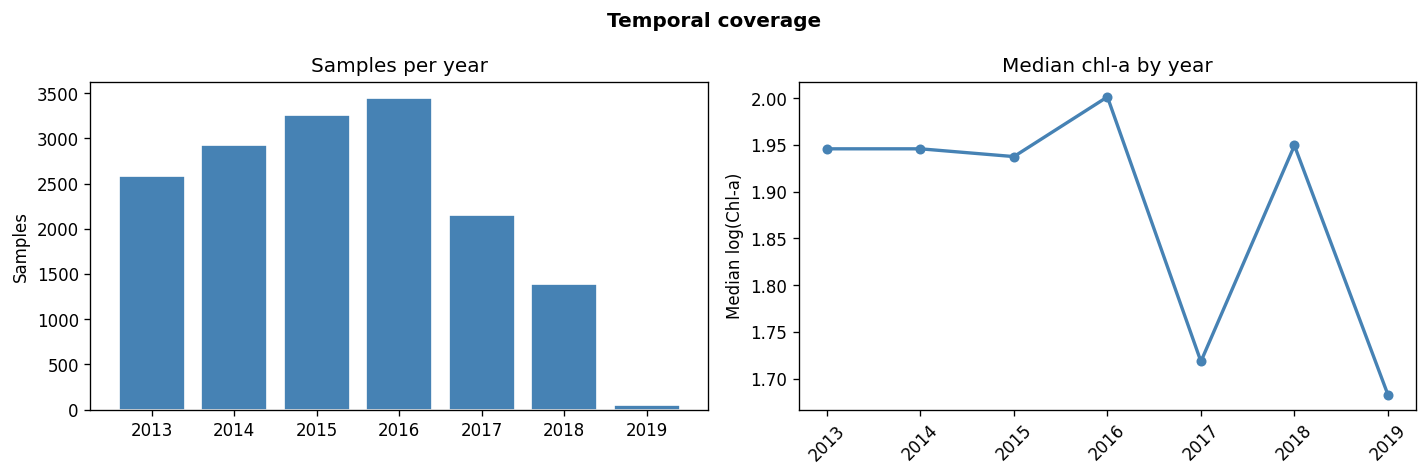

In [7]:
df8["year"] = pd.to_datetime(df8["date"], errors="coerce").dt.year

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Temporal coverage", fontweight="bold")

year_counts = df8["year"].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="white")
axes[0].set_ylabel("Samples")
axes[0].set_title("Samples per year")

yearly_stats = df8.groupby("year")["log_chl"].median()
axes[1].plot(yearly_stats.index, yearly_stats.values,
             color="steelblue", lw=2, marker="o", ms=5)
axes[1].set_ylabel("Median log(Chl-a)")
axes[1].set_title("Median chl-a by year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### spatial coverage

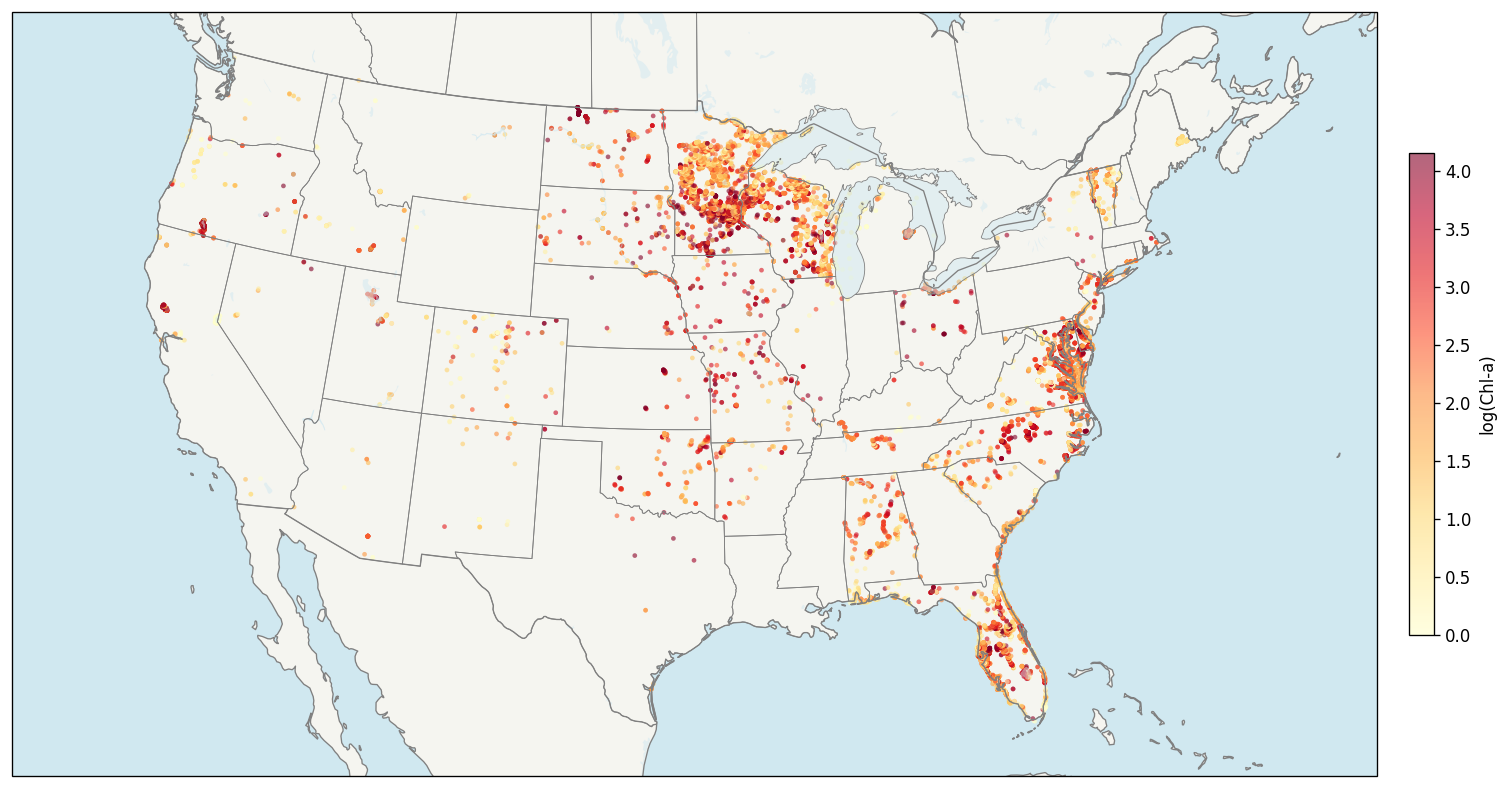

In [8]:
fig, ax = plt.subplots(figsize=(14, 7),
                       subplot_kw={"projection": ccrs.AlbersEqualArea(
                           central_longitude=-96, central_latitude=38)})

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND, facecolor="#f5f5f0")
ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f0")
ax.add_feature(cfeature.LAKES, facecolor="#d0e8f0", alpha=0.5)
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
ax.add_feature(cfeature.BORDERS, edgecolor="gray", linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, edgecolor="gray", linewidth=0.8)

# Plot all points
sc = ax.scatter(df8["long"], df8["lat"],
                c=df8["log_chl"], cmap="YlOrRd",
                s=8, alpha=0.6, linewidths=0,
                vmin=df8["log_chl"].quantile(0.05),
                vmax=df8["log_chl"].quantile(0.95),
                transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax, label="log(Chl-a)", shrink=0.6, pad=0.02)
# ax.set_title("Geographic distribution of Landsat 8 chl-a matchups (n=15,827)")

plt.tight_layout()
plt.show()

### train/val/test split

In [9]:
FEATURES = ["blue", "green", "red", "nir", "swir1", "swir2",
            "green_red", "nir_red", "blue_green", "nir_green"]

# check for inf values
print("Inf values per feature:")
for f in FEATURES:
    n_inf = np.isinf(df8[f]).sum()
    n_nan = np.isnan(df8[f]).sum()
    if n_inf > 0 or n_nan > 0:
        print(f"  {f:<15} inf={n_inf}  nan={n_nan}")

# remove rows with any inf or nan in features
mask = np.isfinite(df8[FEATURES]).all(axis=1)
print(f"\nRows removed due to inf/nan: {(~mask).sum()}")
df8 = df8[mask].copy()
print(f"Remaining: {len(df8):,}")

# split
X = df8[FEATURES].values #inputs
y = df8["log_chl"].values # target

# bin log_chl into 10 equal groups
strat_bins = pd.qcut(df8["log_chl"], q=10, labels=False)

# 80:20 split
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, strat_bins, test_size=0.2, random_state=42, stratify=strat_bins)

# split 20 -> 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=strat_temp)

print(f"\nTrain: {len(X_train):,}")
print(f"Val:   {len(X_val):,}")
print(f"Test:  {len(X_test):,}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("\nScaling check:")
print(f"  Feature means (should be ~0): {X_train.mean(axis=0).round(3)}")
print(f"  Feature stds  (should be ~1): {X_train.std(axis=0).round(3)}")

Inf values per feature:
  green_red       inf=2  nan=0
  nir_red         inf=2  nan=0

Rows removed due to inf/nan: 2
Remaining: 15,825

Train: 12,660
Val:   1,582
Test:  1,583

Scaling check:
  Feature means (should be ~0): [ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0.]
  Feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Baseline Models

### linear regression green-blue

Band-ratio regression (blue/green and log chla):
RMSE (log-space): 1.1983
R2 (log-space): 0.1341
RMSE (µg/L): 33.66


<function matplotlib.pyplot.show(close=None, block=None)>

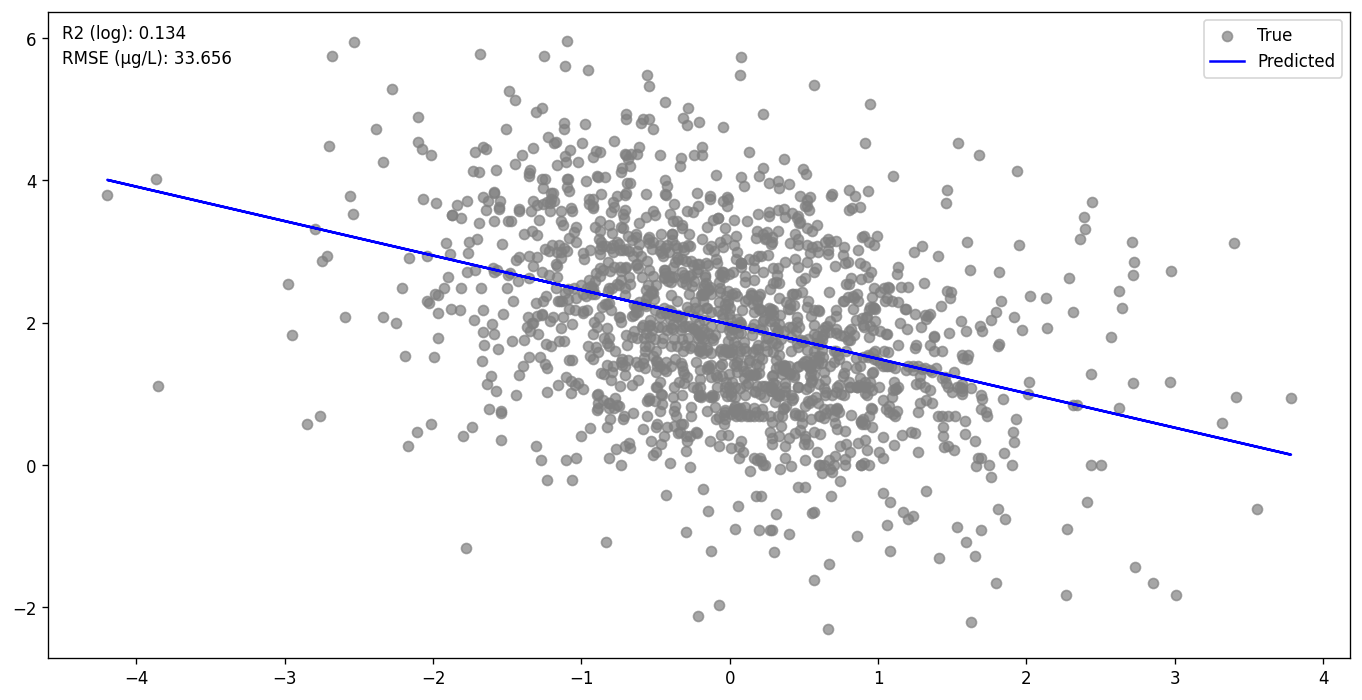

In [10]:
# Blue/green is strongest single predictor
# find the blue-green in index
bg_idx = FEATURES.index("blue_green")

X_train_bg = X_train[:, bg_idx].reshape(-1, 1)
X_val_bg   = X_val[:,   bg_idx].reshape(-1, 1)
X_test_bg  = X_test[:,  bg_idx].reshape(-1, 1)

# fit linear regression on log(chl) ~ blue/green
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_bg, y_train)

# Evaluate on validation set
y_val_pred_lr = lr.predict(X_val_bg)

rmse_lr_log = root_mean_squared_error(y_val, y_val_pred_lr)
r2_lr_log   = r2_score(y_val, y_val_pred_lr)

# convert back to original scale
rmse_lr_orig = root_mean_squared_error(np.exp(y_val), np.exp(y_val_pred_lr))

print("Band-ratio regression (blue/green and log chla):")
print(f"RMSE (log-space): {rmse_lr_log:.4f}")
print(f"R2 (log-space): {r2_lr_log:.4f}")
print(f"RMSE (µg/L): {rmse_lr_orig:.2f}")

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(X_val_bg, y_val, color='gray', alpha=0.7, label="True")
ax.plot(X_val_bg, y_val_pred_lr, color='blue', label="Predicted")
ax.text(-4.5,6, f'R2 (log): {r2_lr_log:.3f}')
ax.text(-4.5,5.65, f'RMSE (µg/L): {rmse_lr_orig:.3f}')
ax.legend()


plt.show

### XGBoost

In [11]:
!pip install xgboost -q

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

y_val_pred_xgb = xgb.predict(X_val)

rmse_xgb_log  = root_mean_squared_error(y_val, y_val_pred_xgb)
r2_xgb_log    = r2_score(y_val, y_val_pred_xgb)
rmse_xgb_orig = root_mean_squared_error(np.exp(y_val), np.exp(y_val_pred_xgb))

print("XGBoost:")
print(f"Val RMSE (log-space): {rmse_xgb_log:.4f}")
print(f"Val R² (log-space): {r2_xgb_log:.4f}")
print(f"Val RMSE (µg/L): {rmse_xgb_orig:.2f}")

XGBoost:
Val RMSE (log-space): 0.9855
Val R² (log-space): 0.4143
Val RMSE (µg/L): 29.19


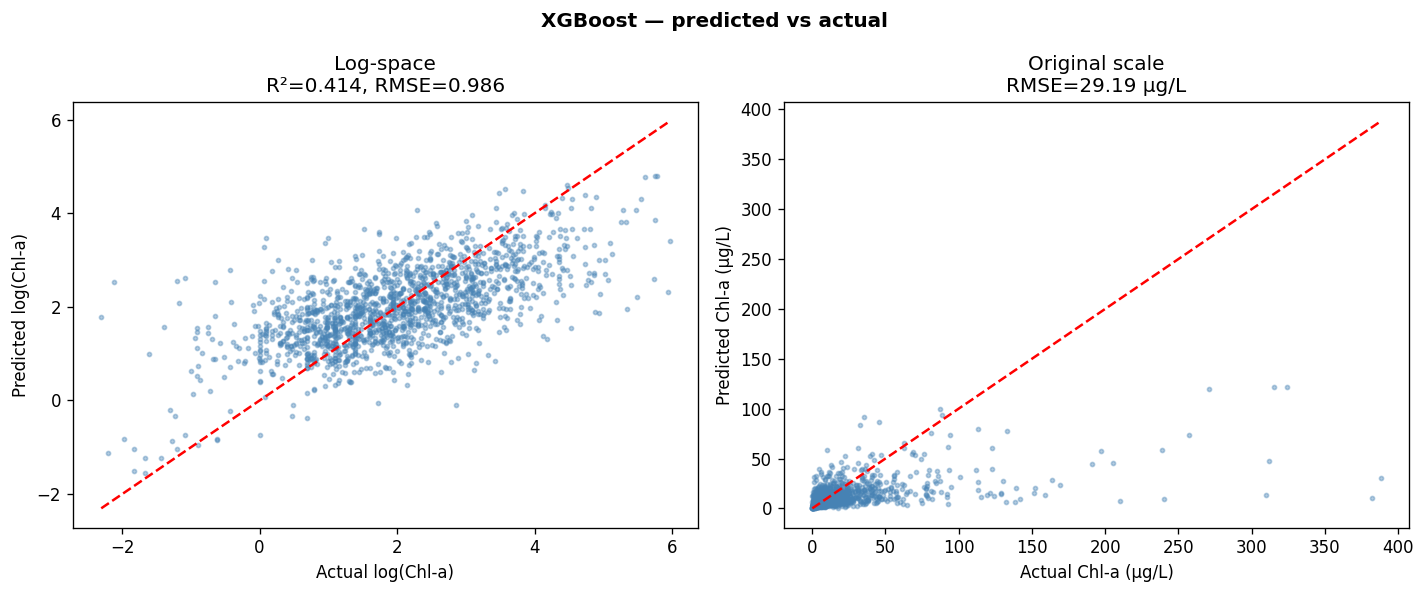

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("XGBoost — predicted vs actual", fontweight="bold")

# Log space
axes[0].scatter(y_val, y_val_pred_xgb, s=6, alpha=0.4, color="steelblue")
mn, mx = y_val.min(), y_val.max()
axes[0].plot([mn, mx], [mn, mx], "r--", lw=1.5)
axes[0].set_xlabel("Actual log(Chl-a)")
axes[0].set_ylabel("Predicted log(Chl-a)")
axes[0].set_title(f"Log-space\nR²={r2_xgb_log:.3f}, RMSE={rmse_xgb_log:.3f}")

# Original scale
axes[1].scatter(np.exp(y_val), np.exp(y_val_pred_xgb), s=6, alpha=0.4, color="steelblue")
mn, mx = np.exp(y_val).min(), np.exp(y_val).max()
axes[1].plot([mn, mx], [mn, mx], "r--", lw=1.5)
axes[1].set_xlabel("Actual Chl-a (µg/L)")
axes[1].set_ylabel("Predicted Chl-a (µg/L)")
axes[1].set_title(f"Original scale\nRMSE={rmse_xgb_orig:.2f} µg/L")

plt.tight_layout()
plt.savefig("fig_xgb_predictions.png", bbox_inches="tight")
plt.show()

### MLP

#### setup

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# define device
device = torch.device("cpu")

# convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

# create DataLoaders for batching
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"Train batches per epoch: {len(train_loader)}")

Train batches per epoch: 50


#### build nn

In [14]:
class MLP(nn.Module):
    def __init__(self, input_dim=10, dropout=0.2):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Output
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

# print summary
model = MLP(input_dim=10).to(device)
print(model)

# get trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 12,225


#### train mlp

In [15]:
def train_mlp(model, train_loader, X_val_t, y_val_t, epochs=200, lr=0.001, patience=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss    = float("inf")
    best_weights     = None
    patience_counter = 0
    history          = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss  = criterion(val_preds, y_val_t).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    model.load_state_dict(best_weights)
    return history

history = train_mlp(model, train_loader, X_val_t, y_val_t)

Epoch  20 | Train: 1.1389 | Val: 1.0464
Epoch  40 | Train: 1.0795 | Val: 1.0255
Epoch  60 | Train: 1.0508 | Val: 1.0155
Epoch  80 | Train: 1.0321 | Val: 1.0700
Epoch 100 | Train: 1.0143 | Val: 0.9941
Epoch 120 | Train: 1.0054 | Val: 0.9884
Early stopping at epoch 121


#### plot loss curves

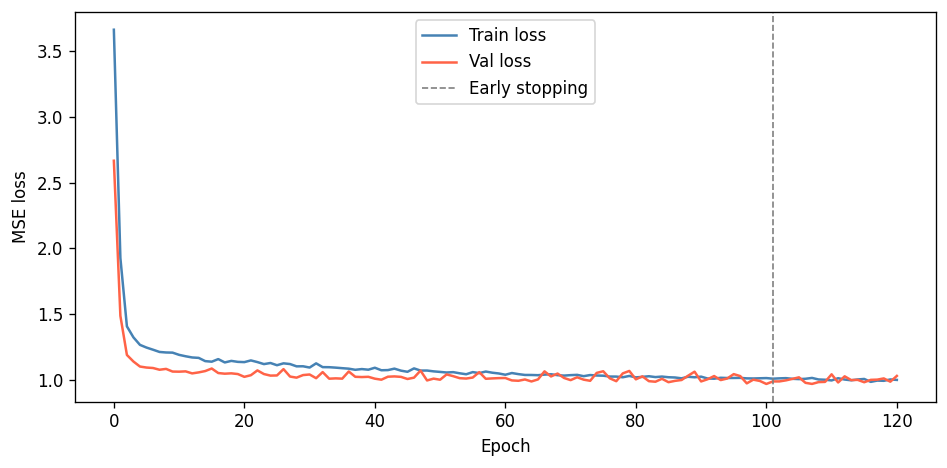

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(history["train_loss"], label="Train loss", color="steelblue")
ax.plot(history["val_loss"],   label="Val loss",   color="tomato")
ax.axvline(len(history["val_loss"]) - 20, color="gray", ls="--", lw=1,
           label="Early stopping")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()

plt.tight_layout()
plt.show()

#### prediction vs truth

Plain MLP Validation:
 RMSE (log-space): 0.9855
 R² (log-space): 0.4144
 RMSE (µg/L): 30.49


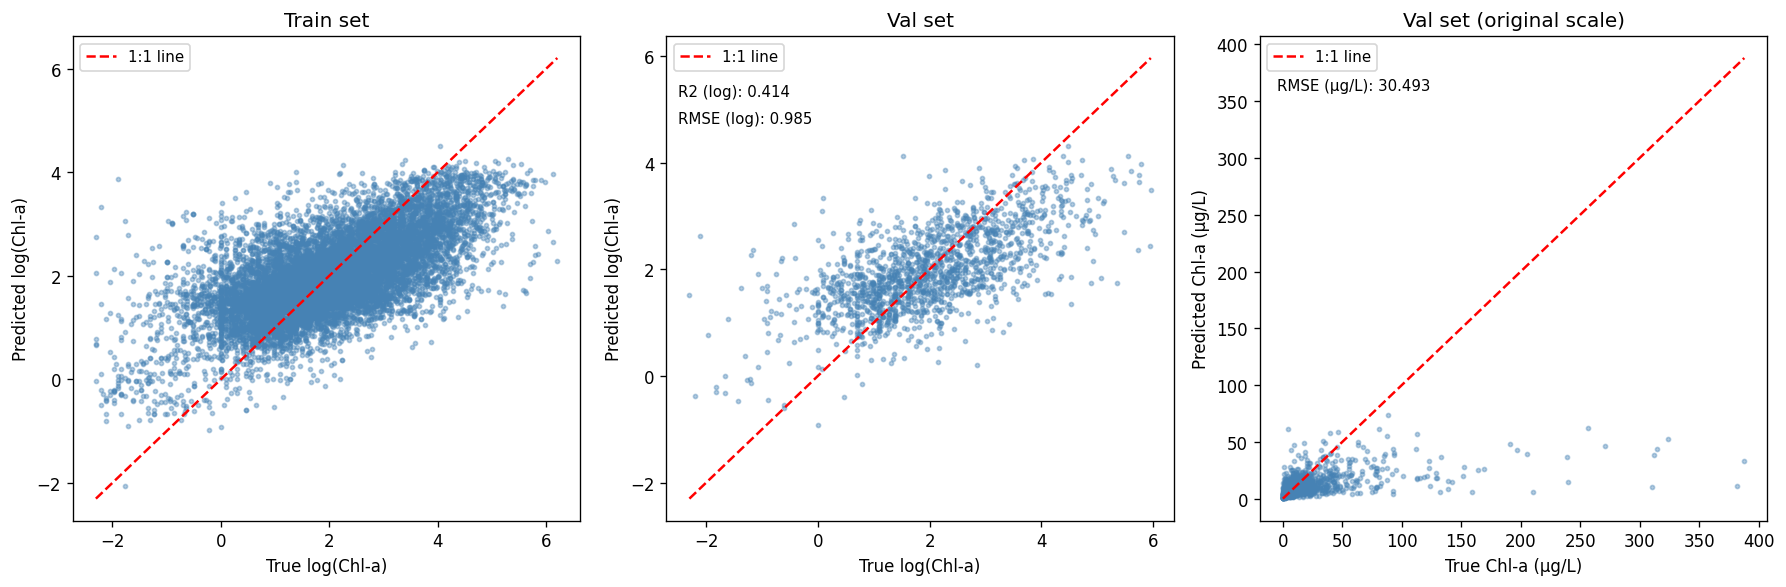

In [17]:
model.eval()
with torch.no_grad():
    y_val_pred_mlp_pt  = model(X_val_t).cpu().numpy()
    y_test_pred_mlp_pt = model(X_test_t).cpu().numpy()

# Metrics
rmse_val_log  = root_mean_squared_error(y_val, y_val_pred_mlp_pt)
r2_val_log    = r2_score(y_val, y_val_pred_mlp_pt)
rmse_val_orig = root_mean_squared_error(np.exp(y_val), np.exp(y_val_pred_mlp_pt))

print("Plain MLP Validation:")
print(f" RMSE (log-space): {rmse_val_log:.4f}")
print(f" R² (log-space): {r2_val_log:.4f}")
print(f" RMSE (µg/L): {rmse_val_orig:.2f}")

# Plot predicted vs actual — three panels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train,          y_val,            y_val],
    [model(X_train_t).detach().cpu().numpy(), y_val_pred_mlp_pt, y_val_pred_mlp_pt],
    ["Train set",      "Val set",        "Val set (original scale)"]
):
    if title == "Val set (original scale)":
        y_true_plot = np.exp(y_true)
        y_pred_plot = np.exp(y_pred)
        label = "Chl-a (µg/L)"
    else:
        y_true_plot = y_true
        y_pred_plot = y_pred
        label = "log(Chl-a)"

    ax.scatter(y_true_plot, y_pred_plot, s=6, alpha=0.4, color="steelblue")
    mn = min(y_true_plot.min(), y_pred_plot.min())
    mx = max(y_true_plot.max(), y_pred_plot.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="1:1 line")
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Predicted {label}")
    ax.set_title(title)
    ax.legend(fontsize=9)
axes[1].text(-2.5,5.25, f'R2 (log): {r2_val_log:.3f}', fontsize=9)
axes[1].text(-2.5,4.75, f'RMSE (log): {rmse_val_log:.3f}', fontsize=9)
axes[2].text(-5,360, f'RMSE (µg/L): {rmse_val_orig:.3f}', fontsize=9)
plt.tight_layout()
plt.show()

### Combined Predictions - baselines

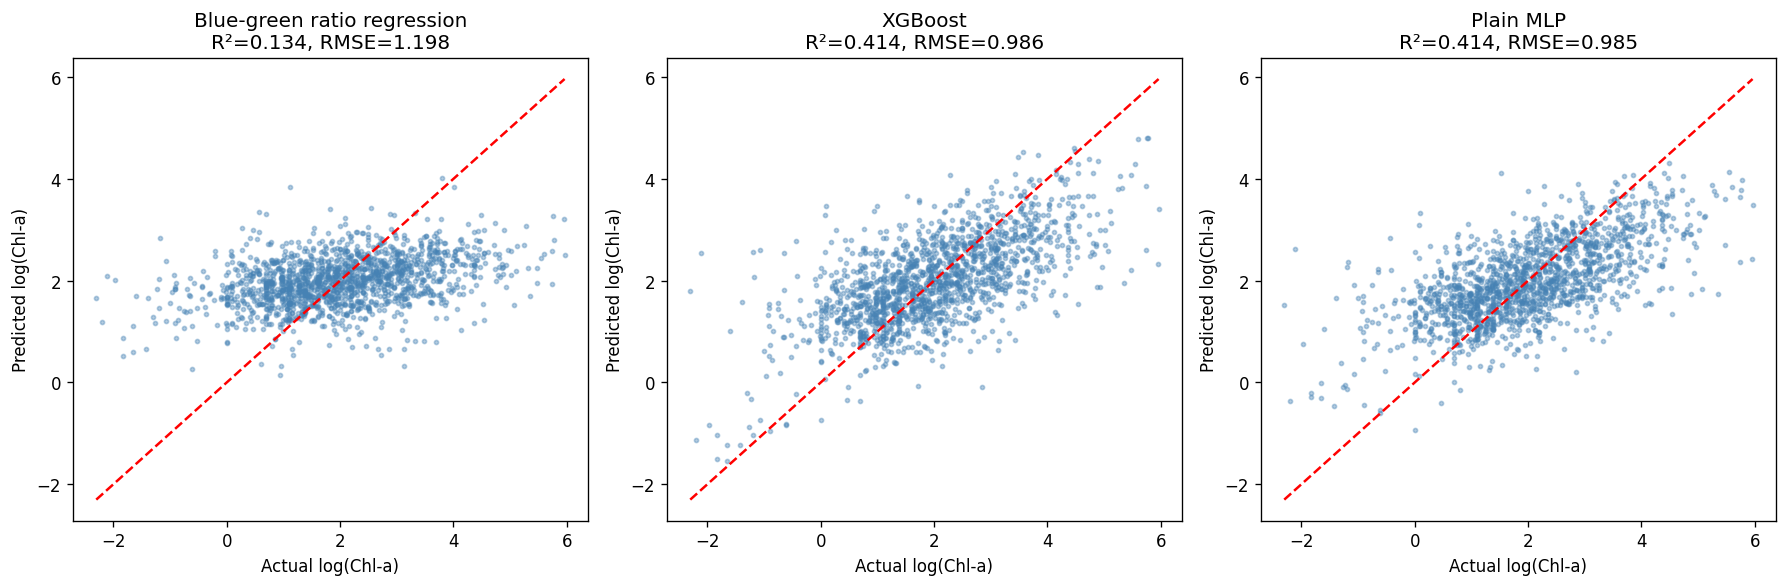

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# fig.suptitle("Predicted vs actual log(chl-a)")

models_preds = [
    (y_val_pred_lr,      "Blue-green ratio regression"),
    (y_val_pred_xgb,     "XGBoost"),
    (y_val_pred_mlp_pt,  "Plain MLP"),
]

for ax, (y_pred, title) in zip(axes, models_preds):
    r2   = r2_score(y_val, y_pred)
    rmse = root_mean_squared_error(y_val, y_pred)

    ax.scatter(y_val, y_pred, s=6, alpha=0.4, color="steelblue")
    mn = min(y_val.min(), y_pred.min())
    mx = max(y_val.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.5)
    ax.set_xlabel("Actual log(Chl-a)")
    ax.set_ylabel("Predicted log(Chl-a)")
    ax.set_title(f"{title}\nR²={r2:.3f}, RMSE={rmse:.3f}")

plt.tight_layout()
# plt.savefig("fig_predictions_all.png", bbox_inches="tight", dpi=150)
plt.show()

## Physics Informed Model

### build nn

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# define device
device = torch.device("cpu")

# identical to baseline
class PhysicsMLPP(nn.Module):
    def __init__(self, input_dim=10, dropout=0.2):
        super(PhysicsMLPP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

### pass raw bands to loss

In [20]:
# store raw band values as tensors
band_idx = [FEATURES.index(b) for b in ["blue","green","red","nir","swir1","swir2"]]

# inverse transform to get original scale
X_train_raw = torch.tensor(
    scaler.inverse_transform(X_train)[:, :6], dtype=torch.float32).to(device)
X_val_raw   = torch.tensor(
    scaler.inverse_transform(X_val)[:, :6],   dtype=torch.float32).to(device)

# recompute tau from actual nir values
nir_train_raw = scaler.inverse_transform(X_train)[:, 3]
tau_nir = float(np.percentile(nir_train_raw, 90))
print(f"NIR threshold (tau) at 90th percentile: {tau_nir:.4f}")

# create new dataloader that includes raw bands
train_dataset_raw = TensorDataset(X_train_t, y_train_t, X_train_raw)
train_loader_raw  = DataLoader(train_dataset_raw, batch_size=256, shuffle=True)

NIR threshold (tau) at 90th percentile: 0.0566


### custom loss function

In [21]:
def physics_loss(y_pred, y_true, x_raw, lambda1=0.01, lambda2=0.01, tau=0.05):
    # x_raw contains original scale band values: blue, green, red, nir, swir1, swir2
    mse   = nn.MSELoss()(y_pred, y_true)

    blue  = x_raw[:, 0]
    green = x_raw[:, 1]
    red   = x_raw[:, 2]
    nir   = x_raw[:, 3]

    # smoothness on visible + NIR only
    diff1 = (green - blue)  ** 2
    diff2 = (red   - green) ** 2
    diff3 = (nir   - red)   ** 2
    smoothness  = (diff1 + diff2 + diff3).mean()

    # NIR baseline
    nir_penalty = (torch.clamp(nir - tau, min=0) ** 2).mean()

    total = mse + lambda1 * smoothness + lambda2 * nir_penalty
    return total, mse, smoothness, nir_penalty

### train

In [22]:
def train_physics_mlp(model, train_loader, X_val_t, y_val_t,
                          lambda1=0.01, lambda2=0.01, tau=0.05,
                          epochs=200, lr=0.001, patience=20):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss    = float("inf")
    best_weights     = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [],
               "mse": [], "smoothness": [], "nir_penalty": []}

    for epoch in range(epochs):
        model.train()
        train_loss = epoch_mse = epoch_smooth = epoch_nir = 0

        for X_batch, y_batch, X_raw_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss, mse, smooth, nir = physics_loss(
                preds, y_batch, X_raw_batch, lambda1, lambda2, tau)
            loss.backward()
            optimizer.step()
            train_loss   += loss.item()
            epoch_mse    += mse.item()
            epoch_smooth += smooth.item()
            epoch_nir    += nir.item()

        train_loss   /= len(train_loader)
        epoch_mse    /= len(train_loader)
        epoch_smooth /= len(train_loader)
        epoch_nir    /= len(train_loader)

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss  = nn.MSELoss()(val_preds, y_val_t).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["mse"].append(epoch_mse)
        history["smoothness"].append(epoch_smooth)
        history["nir_penalty"].append(epoch_nir)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.4f} | "
                  f"Val MSE: {val_loss:.4f} | "
                  f"Smooth: {epoch_smooth:.4f} | NIR: {epoch_nir:.4f}")

    model.load_state_dict(best_weights)
    return history

In [23]:
# start with small lambda values
physics_model = PhysicsMLPP(input_dim=10).to(device)

history_physics = train_physics_mlp(
    physics_model,
    train_loader_raw,
    X_val_t,
    y_val_t,
    lambda1=0.01,
    lambda2=0.01,
    epochs=200,
    lr=0.001,
    patience=20
)

Epoch  20 | Train: 1.1281 | Val MSE: 1.0276 | Smooth: 0.0007 | NIR: 0.0010
Epoch  40 | Train: 1.0841 | Val MSE: 1.0341 | Smooth: 0.0008 | NIR: 0.0010
Epoch  60 | Train: 1.0382 | Val MSE: 0.9955 | Smooth: 0.0007 | NIR: 0.0010
Epoch  80 | Train: 1.0136 | Val MSE: 0.9882 | Smooth: 0.0007 | NIR: 0.0010
Epoch 100 | Train: 0.9983 | Val MSE: 0.9831 | Smooth: 0.0007 | NIR: 0.0010
Early stopping at epoch 110


### evaluate

In [24]:
physics_model.eval()
with torch.no_grad():
    y_val_pred_physics = physics_model(X_val_t).cpu().numpy()

rmse_physics_log  = root_mean_squared_error(y_val, y_val_pred_physics)
r2_physics_log    = r2_score(y_val, y_val_pred_physics)
rmse_physics_orig = root_mean_squared_error(np.exp(y_val), np.exp(y_val_pred_physics))

print("Physics-informed MLP (lambda1=0.01, lambda2=0.01):")
print(f"  Val RMSE (log-space):  {rmse_physics_log:.4f}")
print(f"  Val R²   (log-space):  {r2_physics_log:.4f}")
print(f"  Val RMSE (µg/L):       {rmse_physics_orig:.2f}")

print("\nComparison so far:")
print(f"  Band-ratio regression: R²={r2_lr_log:.2f}, RMSE (log)={rmse_lr_log:.2f}")
print(f"  XGBoost:               R²={r2_xgb_log:.2f}, RMSE (log)={rmse_xgb_log:.2f}")
print(f"  Plain MLP:             R²={r2_val_log:.2f}, RMSE (log)={rmse_val_log:.2f}")
print(f"  Physics MLP (λ=0.01):  R²={r2_physics_log:.2f}, RMSE={rmse_physics_log:.2f}")

Physics-informed MLP (lambda1=0.01, lambda2=0.01):
  Val RMSE (log-space):  0.9902
  Val R²   (log-space):  0.4087
  Val RMSE (µg/L):       30.72

Comparison so far:
  Band-ratio regression: R²=0.13, RMSE (log)=1.20
  XGBoost:               R²=0.41, RMSE (log)=0.99
  Plain MLP:             R²=0.41, RMSE (log)=0.99
  Physics MLP (λ=0.01):  R²=0.41, RMSE=0.99


## Test all Models

In [25]:
physics_model.eval()
model.eval()
with torch.no_grad():
    y_test_pred_physics = physics_model(X_test_t).cpu().numpy()
    y_test_pred_mlp     = model(X_test_t).cpu().numpy()

y_test_pred_xgb = xgb.predict(X_test)
y_test_pred_lr  = lr.predict(X_test[:, FEATURES.index("blue_green")].reshape(-1, 1))

print("=" * 55)
print("FINAL TEST SET RESULTS")
print("=" * 55)

models = [
    ("Band-ratio regression", y_test_pred_lr),
    ("XGBoost",               y_test_pred_xgb),
    ("Plain MLP",             y_test_pred_mlp),
    ("Physics-informed MLP",  y_test_pred_physics),
]

for name, y_pred in models:
    rmse_log  = root_mean_squared_error(y_test, y_pred)
    r2_log    = r2_score(y_test, y_pred)
    rmse_orig = root_mean_squared_error(np.exp(y_test), np.exp(y_pred))
    print(f"\n{name}:")
    print(f"  RMSE (log):  {rmse_log:.4f}")
    print(f"  R²   (log):  {r2_log:.4f}")
    print(f"  RMSE (µg/L): {rmse_orig:.2f}")

FINAL TEST SET RESULTS

Band-ratio regression:
  RMSE (log):  1.2007
  R²   (log):  0.1337
  RMSE (µg/L): 30.33

XGBoost:
  RMSE (log):  0.9893
  R²   (log):  0.4119
  RMSE (µg/L): 25.97

Plain MLP:
  RMSE (log):  0.9907
  R²   (log):  0.4103
  RMSE (µg/L): 26.86

Physics-informed MLP:
  RMSE (log):  0.9905
  R²   (log):  0.4104
  RMSE (µg/L): 27.14


# Regional (CBW)

## Data prep

### Check data in Chesapeake Bay Watershed

In [26]:
import geopandas as gpd
from shapely.geometry import Point

# Chesapeake Bay watershed boundary (HUC-4) from USGS/FWS:
# https://gis-fws.opendata.arcgis.com/datasets/chesapeake-bay-watershed-boundary/explore?location=39.826191%2C-77.565341%2C5
# Download the shapefile and update the path below
chesapeake = gpd.read_file("path/to/Chesapeake_Bay_Watershed_Boundary.shp")

# convert to gdf
gdf = gpd.GeoDataFrame(
    df8,
    geometry=gpd.points_from_xy(df8["long"], df8["lat"]),
    crs="EPSG:4326"
)

# match crs
chesapeake = chesapeake.to_crs("EPSG:4326")

# join datasets
df_chesa = gpd.sjoin(gdf, chesapeake, how="inner", predicate="within")
print(f"Samples within Chesapeake watershed: {len(df_chesa):,}")
print(f"Chl-a range: {df_chesa['chl_a'].min():.2f} – {df_chesa['chl_a'].max():.2f} µg/L")

Samples within Chesapeake watershed: 2,248
Chl-a range: 0.10 – 495.00 µg/L


plot

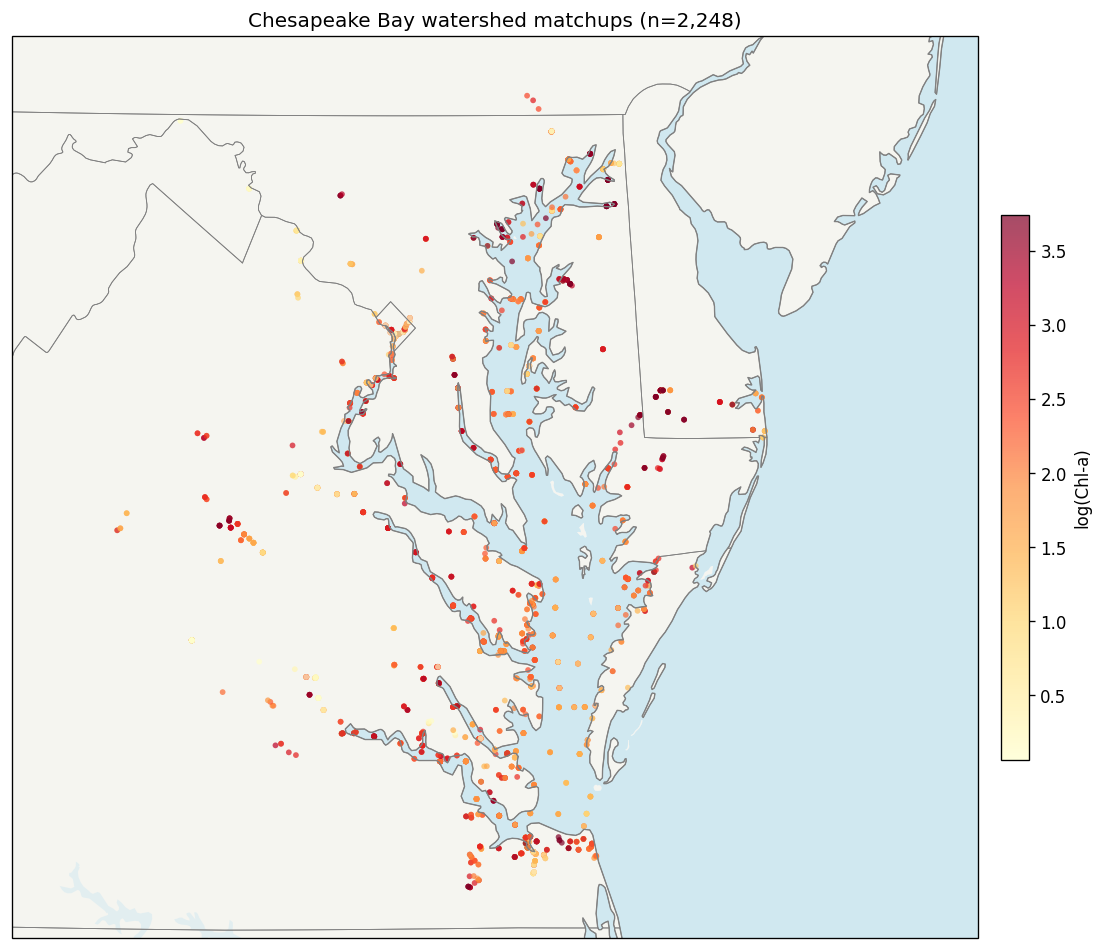

In [27]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10, 8),
                       subplot_kw={"projection": ccrs.AlbersEqualArea(
                           central_longitude=-77, central_latitude=38)})

# zoom into cbw
ax.set_extent([-79, -74, 36.5, 40], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f5f5f0")
ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f0")
ax.add_feature(cfeature.LAKES, facecolor="#d0e8f0", alpha=0.5)
ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, edgecolor="gray", linewidth=0.8)

# plot cbw points only
sc = ax.scatter(df_chesa["long"], df_chesa["lat"],
                c=df_chesa["log_chl"], cmap="YlOrRd",
                s=12, alpha=0.7, linewidths=0,
                vmin=df_chesa["log_chl"].quantile(0.05),
                vmax=df_chesa["log_chl"].quantile(0.95),
                transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax, label="log(Chl-a)", shrink=0.6, pad=0.02)
ax.set_title(f"Chesapeake Bay watershed matchups (n={len(df_chesa):,})")

plt.tight_layout()
plt.savefig("fig_chesapeake_map.png", bbox_inches="tight", dpi=150)
plt.show()

### setup

In [28]:
# features and target
X_c = df_chesa[FEATURES].values
y_c = df_chesa["log_chl"].values

# stratified split
strat_c = pd.qcut(df_chesa["log_chl"], q=10, labels=False)
X_c_train, X_c_temp, y_c_train, y_c_temp, s_c_train, s_c_temp = train_test_split(
    X_c, y_c, strat_c, test_size=0.2, random_state=42, stratify=strat_c)
X_c_val, X_c_test, y_c_val, y_c_test = train_test_split(
    X_c_temp, y_c_temp, test_size=0.5, random_state=42, stratify=s_c_temp)

# scale using Chesapeake training data only
scaler_c  = StandardScaler()
X_c_train = scaler_c.fit_transform(X_c_train)
X_c_val   = scaler_c.transform(X_c_val)
X_c_test  = scaler_c.transform(X_c_test)

print(f"Train: {len(X_c_train):,} | Val: {len(X_c_val):,} | Test: {len(X_c_test):,}")

# tensors
X_c_train_t = torch.tensor(X_c_train, dtype=torch.float32).to(device)
y_c_train_t = torch.tensor(y_c_train, dtype=torch.float32).to(device)
X_c_val_t   = torch.tensor(X_c_val,   dtype=torch.float32).to(device)
y_c_val_t   = torch.tensor(y_c_val,   dtype=torch.float32).to(device)
X_c_test_t  = torch.tensor(X_c_test,  dtype=torch.float32).to(device)
y_c_test_t  = torch.tensor(y_c_test,  dtype=torch.float32).to(device)

# raw bands for physics loss
X_c_train_raw = torch.tensor(
    scaler_c.inverse_transform(X_c_train)[:, :6], dtype=torch.float32).to(device)

tau_nir_c = float(np.percentile(scaler_c.inverse_transform(X_c_train)[:, 3], 90))
print(f"Chesapeake NIR tau: {tau_nir_c:.4f}")

# dataloaders
# batch size smaller bc dataset is smaller
c_train_dataset = TensorDataset(X_c_train_t, y_c_train_t)
c_train_loader  = DataLoader(c_train_dataset, batch_size=128, shuffle=True)

c_train_dataset_raw = TensorDataset(X_c_train_t, y_c_train_t, X_c_train_raw)
c_train_loader_raw  = DataLoader(c_train_dataset_raw, batch_size=128, shuffle=True)

Train: 1,798 | Val: 225 | Test: 225
Chesapeake NIR tau: 0.0547


## Baseline Models

### linear regression

In [29]:
bg_idx = FEATURES.index("blue_green")

lr_c = LinearRegression()
lr_c.fit(X_c_train[:, bg_idx].reshape(-1, 1), y_c_train)
y_c_val_pred_lr = lr_c.predict(X_c_val[:, bg_idx].reshape(-1, 1))

print("Chesapeake band-ratio regression:")
print(f"  Val R²   (log): {r2_score(y_c_val, y_c_val_pred_lr):.4f}")
print(f"  Val RMSE (log): {root_mean_squared_error(y_c_val, y_c_val_pred_lr):.4f}")
print(f"  Val RMSE (µg/L): {root_mean_squared_error(np.exp(y_c_val), np.exp(y_c_val_pred_lr)):.2f}")

Chesapeake band-ratio regression:
  Val R²   (log): 0.0074
  Val RMSE (log): 1.1608
  Val RMSE (µg/L): 21.44


### XGBoost

In [30]:
xgb_c = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_c.fit(X_c_train, y_c_train,
           eval_set=[(X_c_val, y_c_val)],
           verbose=False)
y_c_val_pred_xgb = xgb_c.predict(X_c_val)

print("Chesapeake XGBoost:")
print(f"  Val R²   (log): {r2_score(y_c_val, y_c_val_pred_xgb):.4f}")
print(f"  Val RMSE (log): {root_mean_squared_error(y_c_val, y_c_val_pred_xgb):.4f}")
print(f"  Val RMSE (µg/L): {root_mean_squared_error(np.exp(y_c_val), np.exp(y_c_val_pred_xgb)):.2f}")

Chesapeake XGBoost:
  Val R²   (log): 0.3169
  Val RMSE (log): 0.9629
  Val RMSE (µg/L): 19.05


### Plain mlp

In [31]:
model_c = MLP(input_dim=10).to(device)
history_c = train_mlp(model_c, c_train_loader, X_c_val_t, y_c_val_t)

model_c.eval()
with torch.no_grad():
    y_c_val_pred_mlp = model_c(X_c_val_t).cpu().numpy()

print("Chesapeake plain MLP:")
print(f"  Val R²   (log): {r2_score(y_c_val, y_c_val_pred_mlp):.4f}")
print(f"  Val RMSE (log): {root_mean_squared_error(y_c_val, y_c_val_pred_mlp):.4f}")
print(f"  Val RMSE (µg/L): {root_mean_squared_error(np.exp(y_c_val), np.exp(y_c_val_pred_mlp)):.2f}")

Epoch  20 | Train: 1.1377 | Val: 1.1357
Epoch  40 | Train: 1.0636 | Val: 1.0883
Early stopping at epoch 59
Chesapeake plain MLP:
  Val R²   (log): 0.2065
  Val RMSE (log): 1.0378
  Val RMSE (µg/L): 19.82


## Physics informed mlp

In [32]:
physics_model_c = PhysicsMLPP(input_dim=10).to(device)
history_physics_c = train_physics_mlp(
    physics_model_c,
    c_train_loader_raw,
    X_c_val_t,
    y_c_val_t,
    lambda1=0.01,
    lambda2=0.01,
    tau=tau_nir_c,
    epochs=200,
    lr=0.001,
    patience=20
)

physics_model_c.eval()
with torch.no_grad():
    y_c_val_pred_physics = physics_model_c(X_c_val_t).cpu().numpy()

print("Chesapeake physics MLP:")
print(f"  Val R²   (log): {r2_score(y_c_val, y_c_val_pred_physics):.4f}")
print(f"  Val RMSE (log): {root_mean_squared_error(y_c_val, y_c_val_pred_physics):.4f}")
print(f"  Val RMSE (µg/L): {root_mean_squared_error(np.exp(y_c_val), np.exp(y_c_val_pred_physics)):.2f}")

Epoch  20 | Train: 1.1034 | Val MSE: 1.1146 | Smooth: 0.0008 | NIR: 0.0004
Epoch  40 | Train: 1.0137 | Val MSE: 1.1198 | Smooth: 0.0008 | NIR: 0.0004
Epoch  60 | Train: 0.9971 | Val MSE: 1.1036 | Smooth: 0.0008 | NIR: 0.0004
Early stopping at epoch 67
Chesapeake physics MLP:
  Val R²   (log): 0.2026
  Val RMSE (log): 1.0404
  Val RMSE (µg/L): 19.69


# Final Plots

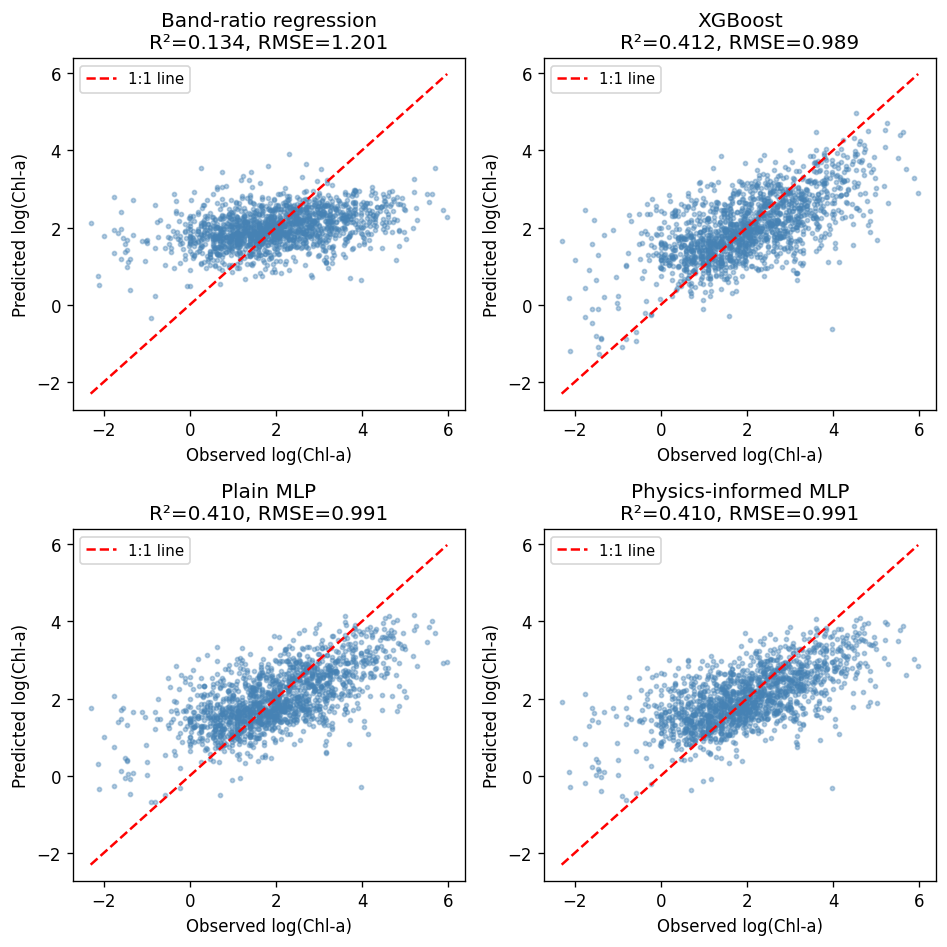

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
# fig.suptitle("Predicted vs actual log(chl-a) — test set",
#              fontweight="bold", fontsize=13)

models_preds = [
    (y_test_pred_lr,      "Band-ratio regression"),
    (y_test_pred_xgb,     "XGBoost"),
    (y_test_pred_mlp,     "Plain MLP"),
    (y_test_pred_physics, "Physics-informed MLP"),
]

for ax, (y_pred, title) in zip(axes.flatten(), models_preds):
    r2   = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, s=6, alpha=0.4, color="steelblue")
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="1:1 line")
    ax.set_xlabel("Observed log(Chl-a)")
    ax.set_ylabel("Predicted log(Chl-a)")
    ax.set_title(f"{title}\nR²={r2:.3f}, RMSE={rmse:.3f}")
    ax.legend(fontsize=9)

plt.tight_layout()

# plt.savefig("fig_predictions_all.png", bbox_inches="tight", dpi=150)
plt.show()

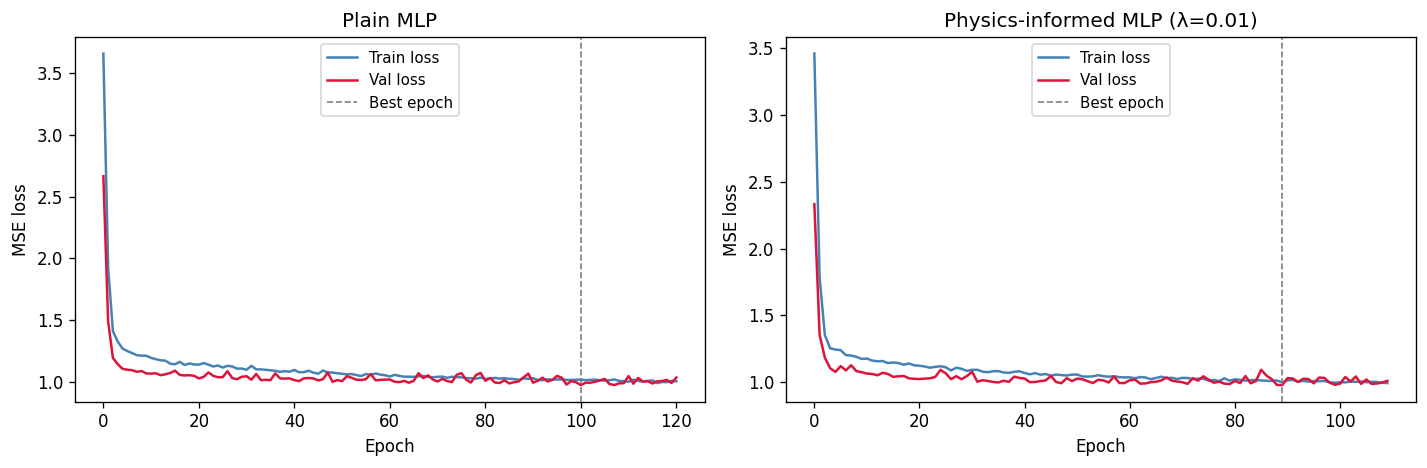

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in zip(
    axes,
    [history, history_physics],
    ["Plain MLP", "Physics-informed MLP (λ=0.01)"]
):
    ax.plot(hist["train_loss"], color="steelblue", label="Train loss")
    ax.plot(hist["val_loss"],   color="crimson",   label="Val loss")
    best_epoch = hist["val_loss"].index(min(hist["val_loss"]))
    ax.axvline(best_epoch, color="gray", ls="--", lw=1, label="Best epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_loss_curves.png", bbox_inches="tight", dpi=150)
plt.show()

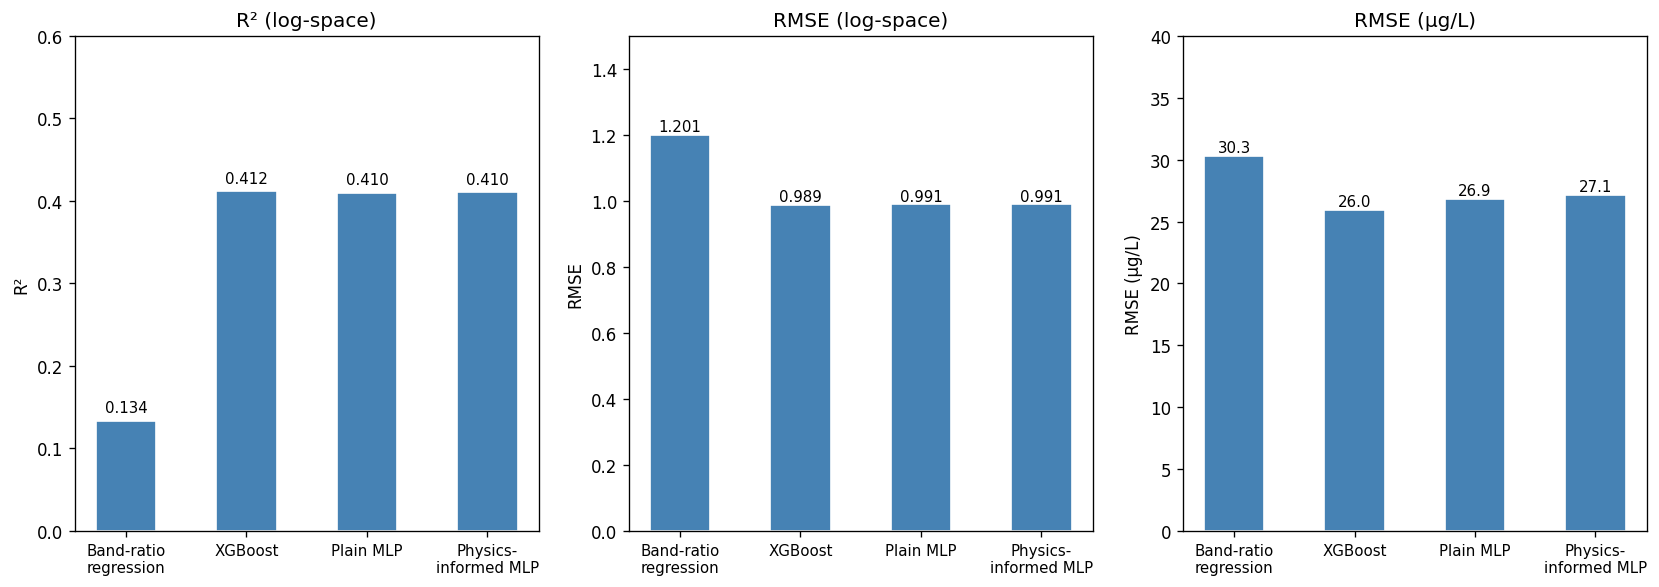

In [35]:
models = ["Band-ratio\nregression", "XGBoost", "Plain MLP", "Physics-\informed MLP"]

r2_scores = [r2_score(y_test, p) for p in [y_test_pred_lr, y_test_pred_xgb, y_test_pred_mlp, y_test_pred_physics]]
rmse_log  = [root_mean_squared_error(y_test, p) for p in [y_test_pred_lr, y_test_pred_xgb, y_test_pred_mlp, y_test_pred_physics]]
rmse_orig = [root_mean_squared_error(np.exp(y_test), np.exp(p)) for p in [y_test_pred_lr, y_test_pred_xgb, y_test_pred_mlp, y_test_pred_physics]]

x = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(x, r2_scores, width=0.5, color="steelblue", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel("R²")
axes[0].set_title("R² (log-space)")
axes[0].set_ylim(0, 0.6)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(x, rmse_log, width=0.5, color="steelblue", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE (log-space)")
axes[1].set_ylim(0, 1.5)
for i, v in enumerate(rmse_log):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

axes[2].bar(x, rmse_orig, width=0.5, color="steelblue", edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylabel("RMSE (µg/L)")
axes[2].set_title("RMSE (µg/L)")
axes[2].set_ylim(0, 40)
for i, v in enumerate(rmse_orig):
    axes[2].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()